In [1]:
import numpy as np
from scipy.stats import norm
from scipy import interpolate
from scipy.misc import derivative as deriv
from astropy.io import fits, ascii
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import scipy.optimize as optimization
from scipy.optimize import curve_fit, least_squares
import matplotlib.pyplot as plt
plt.style.use('junk')


In [63]:
def calc_sb2fit(ELarr, time):
    # Define orbital element parameters
    period = ELarr[0]
    Tperi  = ELarr[1]
    ecc    = ELarr[2]
    K1     = ELarr[3]
    K2     = ELarr[4]
    omega  = ELarr[5]   # RADIANS # omega_A
    Vsys   = ELarr[6]  
    num = len(time)     # however long the time array is
    
    # calc_ei.pro
    # Determine the eccentric anomalies (Ei) as a function of time: 
    #  Ei = angular position of obs position projected up to a circular orbit
    #     mu(ti - T) = Ei - esin(Ei)  ... Kepler's Equation
    #     where mu = 360/P = 2*pi/P
    # Solve this transcendental equation through an iterative procedure.
    # written by Gail Shaefer
    Ei = np.zeros(num) 
    mu = 2 * np.pi / period		# ex - degrees / day

    for i in range(0, num):
        # Mi: mean anomoly - increases uniformly with time
        # zero at time Tperi, 2Pi each orbit
        # percent of orbital period that has passed, expressed as an angle	
        Mi = mu * (time[i] - Tperi) 	
        # deg / day     *     number of days   =   deg 

        # reduce to same epoch
        Mi = 2 * np.pi * (  (time[i] - Tperi)/period - int((time[i] - Tperi)/period) )

        # keep Mi between 0 and 2Pi
        if Mi < 0.0:
            Mi = Mi + 2*np.pi
        if Mi > 2*np.pi:
            Mi = Mi - 2*np.pi

        # solve_trans.pro
        # Solve transcendental equation of the form E - esinE = M.
        # Use iterative procedure to determine E.
        # Initial approximation: E_0 = M + esinM - e^2/2 sin(2M)
        # Improve solution by iterating the following to formulae:
        #	M_0 = E_0 - esin(E_0)
        #	E_1 = E_0 + (M - M_0)/(1 - ecos(E_0))
        #	(derivative of Kepler's equation)
        #
        # Method adapted from Heintz 1978 (p.34-35)
        # Results compared with point-&-click graphical method.  Iterative approach 
        # leads to exact solution that satisfies E - esinE = M.  Therefore, 
        # point-&-click method is subsequently removed from orbit fitting.
        #
        # INPUT:
        #	e: eccentricity
        #	M: mean anomaly   M= 2*Pi/P
        #
        # OUTPUT:
        #	EE: eccentric anomaly
        #
        # Created: 9 May 2002 by Gail Shaefer
        # 12 December 2007: add escape route in case routine doesn't converge

        # Initial approximation:
        # PYTHON SIN USES RADIANS
        EE = Mi + ecc*np.sin(Mi) + ecc**2/2*np.sin(2*Mi)

        EEi = 0.0	# parameter to hold initial value once enter while loop
        count = 0.0

        while ((abs(EE - EEi) > 0.00001) & (count < 10000)):
            EEi = EE
            Mi0 = EEi - ecc*np.sin(EEi)
            EE = EEi + (Mi - Mi0)/(1 - ecc*np.cos(EEi))
            count=count+1

        # return EE
        Eit = EE


        # keep Ei between 0 and 2Pi
        if Eit < 0.0:
            Eit = Eit + 2*np.pi
        if Eit > 2*np.pi:
            Eit = Eit - 2*np.pi

        Ei[i] = Eit	# radians 
        
    # Determine true anomalies (nu)
    # nu = angle around from periastron
    nu = 2*np.arctan(np.sqrt((1+ecc)/(1-ecc))*np.tan(Ei/2.0))	# radians
    # keep nu between 0 and 2Pi
    for i in range(0, num):
        if nu[i] < 0.0: nu[i] = nu[i] + 2*np.pi

    # Check sign of nu
    cosnu = np.cos(nu)
    sinnu = np.sin(nu)
    actualcosnu = (np.cos(Ei) - ecc) / (1-ecc*np.cos(Ei))
    actualsinnu = np.sqrt(1-ecc**2)*np.sin(Ei) / (1-ecc*np.cos(Ei))
    for i in range(0,num):
        if cosnu[i]/abs(cosnu[i]) != actualcosnu[i]/abs(actualcosnu[i]):
            if sinnu[i]/abs(sinnu[i]) != actualsinnu[i]/abs(actualsinnu[i]):
                nu[i] = nu[i] + np.pi
        
    # calculate RV
    V1 = K1 * (ecc*np.cos(omega) + np.cos(nu+omega)) + Vsys
    V2 = -1 * K2 * (ecc*np.cos(omega) + np.cos(nu+omega)) + Vsys
    return(V1, V2)



# new function to calculate residuals
def resid(ELarr, xdata, ydata1, ydata2, sigma1, sigma2):
    ymod1, ymod2 = calc_sb2fit(ELarr, xdata)
    
    #print(ydata1, ymod1, sigma1)
    #ymod1 = calc_sb2fit(xdata, ELarr[0])
    #ymod2 = calc_sb2fit(time, ELarr)
    resid1 = (ydata1 - ymod1)/sigma1
    resid2 = (ydata2 - ymod2)/sigma2

    return np.append(resid1, resid2)   # array, not summed together

In [125]:
# our parameters
#                  P     T0     e   K1  K2  w  V0
ELarr = np.array([27.01773, 601579, 0.2, 60, 120, 180, 45])

time1, rv1, erv1 = np.loadtxt('rv1_todcore.txt', delimiter=',', unpack=True)
time2, rv2, erv2 = np.loadtxt('rv2_todcore.txt', delimiter=',', unpack=True)
erv1 = erv1 * 2
erv2 = erv2 * 2

ind = np.arange(0, len(time1))

print(' nobs = ', len(time1))


 nobs =  16


In [126]:
bounds = ((25, 601570, 0.0,   0,   0,   0,   0), 
          (30, 601590, 0.99, 150, 150, 360, 100))
result0 = least_squares(resid, ELarr, args=(time1, rv1, rv2, erv1, erv2), bounds=bounds)
result2 = result0['x']  # answer
print(result2)

print('Primary Star', "\nPeriod:", result2[0], "\nTperi:", result2[1], "\nEcc:", result2[2], "\nK1:", result2[3], "\nK2:", result2[4], "\nomega:", result2[5], "\nVsys:", result2[6])
#print('Secondary Star', "Period:", model2[0], "Tperi:", model2[1], "Ecc:", model2[2], "K1:", model2[3], "K2:", model2[4], "omega:", model2[5], "Vsys:", model2[6])


[2.70181656e+01 6.01590000e+05 3.81256776e-01 4.69333246e+01
 5.27174893e+01 1.79937631e+02 4.17344380e+01]
Primary Star 
Period: 27.018165608663306 
Tperi: 601589.9998383536 
Ecc: 0.38125677562716304 
K1: 46.9333246140156 
K2: 52.717489291338694 
omega: 179.93763094392884 
Vsys: 41.734438036155645


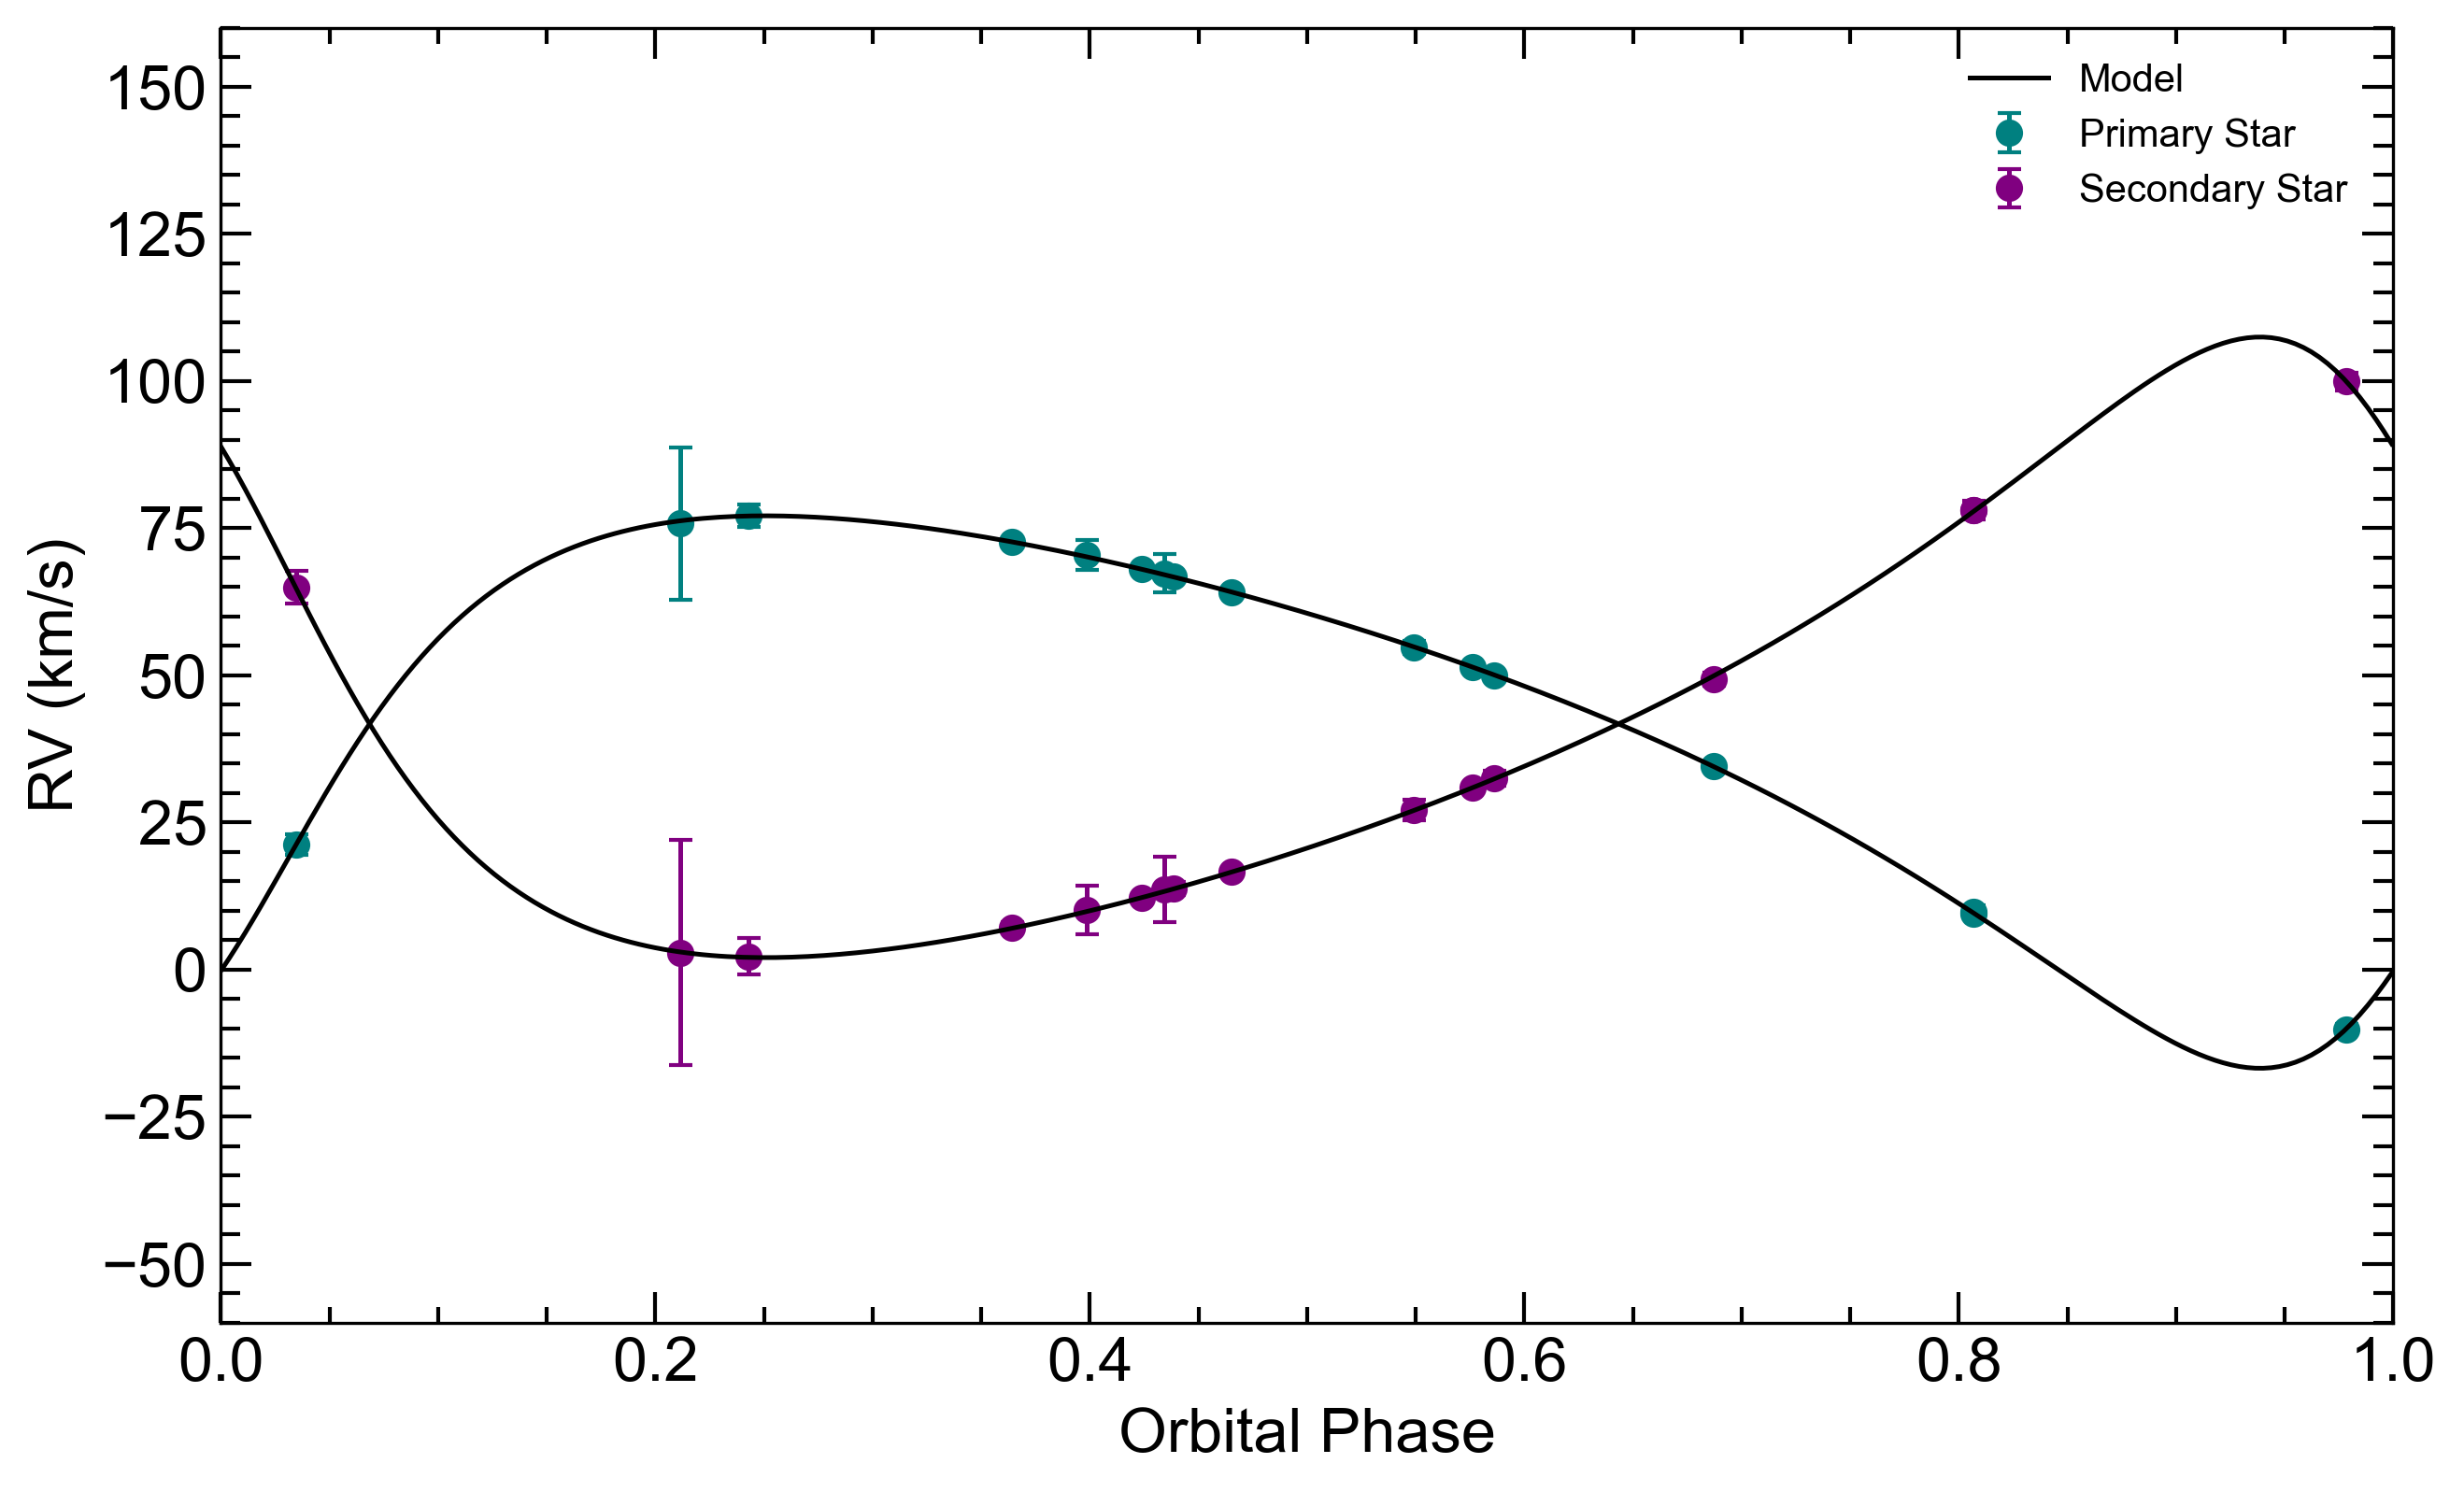

In [129]:
# money plot with error bars, be sure to change names for instrument
p = result2[0]
T = result2[1]
tmod = np.arange(T, T+p, 0.1)

model1, model2 = calc_sb2fit(result2, tmod)
opmod = (tmod - T)/p % 1
op = (time1-T)/p % 1 # calculates phase


plt.figure(figsize=(10,6))
plt.minorticks_on()
plt.plot(opmod, model1, color='black', zorder=3) # plots of the model, zorder is to get the model on top of the observations on the plot
plt.plot(opmod, model2, color='black', label='Model', zorder=3)
plt.errorbar(op, rv1, erv1, fmt="o", label='Primary Star ', color="teal", zorder=2) # plots both the results of rv1 and the rv1 error bars (they're really small)
plt.errorbar(op, rv2, erv2, fmt="o", label='Secondary Star ', color="purple", zorder=1) # same thing as above but with rv2
plt.xlabel("Orbital Phase")
plt.xlim(0,1)
plt.ylim(-60, 160)
plt.ylabel("RV (km/s)")
plt.legend(loc='upper right', fontsize=10)

#for i in ind: plt.text(op[i], rv1[i], ' '+str(i), fontsize=10)
#for i in ind: plt.text(op[i], rv2[i], ' '+str(i), fontsize=10)

plt.savefig('rvcurve_model.png', dpi=300)

